# 🔍 Exploração do Dataset UDPLag (EDA)
**Objetivo:** Entender completamente o que existe no arquivo `UDPLag.csv` antes de qualquer modelagem.

### Seções:
1. Carregamento e visão geral
2. Distribuição de classes
3. Estatísticas descritivas
4. Valores ausentes e infinitos
5. Distribuição das features numéricas
6. Correlação entre features
7. Análise por classe (BENIGN vs UDPLag)
8. Detecção de outliers
9. Conclusões

In [ ]:
# ============================================================
# 0. Instalar dependências (caso necessário no Colab)
# ============================================================
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


---
## 1. Carregamento e Visão Geral

In [ ]:
# ============================================================
# Ajuste o caminho abaixo conforme necessário
# ============================================================
CSV_PATH = '/content/UDPLag.csv'   # Google Colab
# CSV_PATH = './UDPLag.csv'         # Local

df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = df.columns.str.strip()

print(f'📐 Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'💾 Memória estimada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print()
print('📋 Primeiras 5 linhas:')
df.head()

📐 Shape: 725,165 linhas × 88 colunas
💾 Memória estimada: 718.5 MB

📋 Primeiras 5 linhas:


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,50880,172.16.0.5-192.168.50.4-35468-49856-17,172.16.0.5,35468,192.168.50.4,49856,17,2018-11-03 11:01:43.652742,47,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP
1,83164,172.16.0.5-192.168.50.4-44167-44225-17,172.16.0.5,44167,192.168.50.4,44225,17,2018-11-03 11:01:43.653107,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP
2,49389,172.16.0.5-192.168.50.4-36215-28771-17,172.16.0.5,36215,192.168.50.4,28771,17,2018-11-03 11:01:43.653383,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP
3,34687,172.16.0.5-192.168.50.4-44168-43679-17,172.16.0.5,44168,192.168.50.4,43679,17,2018-11-03 11:01:43.653386,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP
4,87466,172.16.0.5-192.168.50.4-52334-44960-17,172.16.0.5,52334,192.168.50.4,44960,17,2018-11-03 11:01:43.653387,880701,18,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP


In [ ]:
# Tipos de dados por coluna
print('📊 Tipos de dados:')
dtype_summary = df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f'   {dtype}: {count} colunas')

print()
print('📋 Colunas não-numéricas:')
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
for c in non_numeric:
    print(f'   • {c}: {df[c].nunique()} valores únicos → {df[c].unique()[:5]}')

📊 Tipos de dados:
   float64: 45 colunas
   int64: 37 colunas
   object: 6 colunas

📋 Colunas não-numéricas:
   • Flow ID: 722970 valores únicos → ['172.16.0.5-192.168.50.4-35468-49856-17'
 '172.16.0.5-192.168.50.4-44167-44225-17'
 '172.16.0.5-192.168.50.4-36215-28771-17'
 '172.16.0.5-192.168.50.4-44168-43679-17'
 '172.16.0.5-192.168.50.4-52334-44960-17']
   • Source IP: 189 valores únicos → ['172.16.0.5' '192.168.50.4' '0.0.0.0' '192.168.50.9' '209.197.3.15']
   • Destination IP: 213 valores únicos → ['192.168.50.4' '172.16.0.5' '255.255.255.255' '87.250.250.119'
 '172.105.219.195']
   • Timestamp: 725147 valores únicos → ['2018-11-03 11:01:43.652742' '2018-11-03 11:01:43.653107'
 '2018-11-03 11:01:43.653383' '2018-11-03 11:01:43.653386'
 '2018-11-03 11:01:43.653387']
   • SimillarHTTP: 48 valores únicos → ['0' 'drmokhberi.ca/2017/09/11/config-sftp-server-on-ubuntu/'
 'drmokhberi.ca/favicon.ico'
 'ocsp2.globalsign.com/gsorganizationvalsha2g2' 'status.geotrust.com/']
   • Label: 4 valo

---
## 2. Distribuição de Classes

📊 Distribuição de classes:
        Contagem  Percentual (%)
Label                           
Syn       606749           83.67
UDP       112475           15.51
BENIGN      4068            0.56
UDPLag      1873            0.26


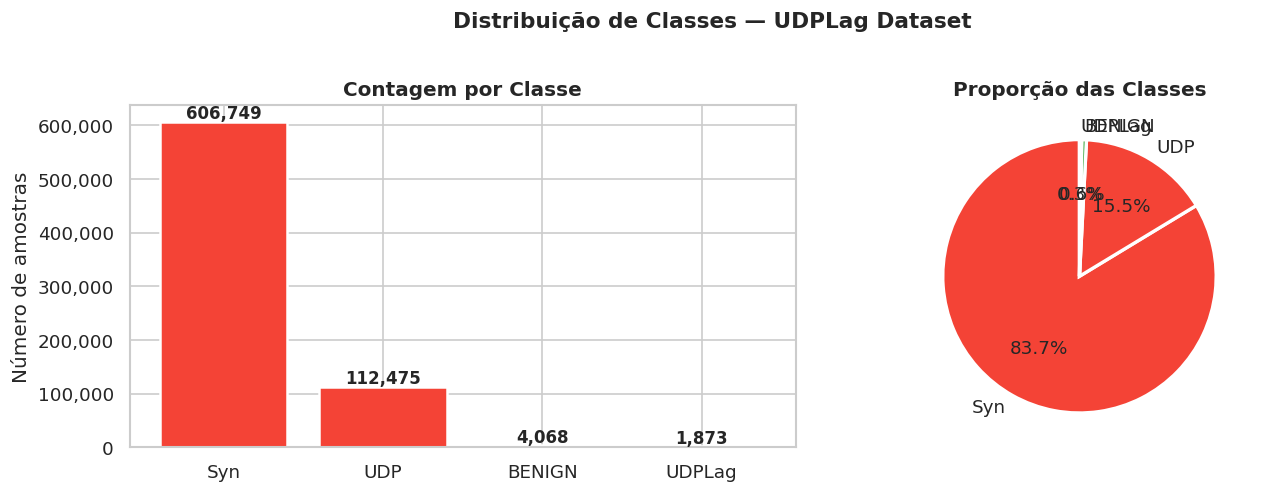


⚖️  Razão de desbalanceamento (maior/menor): 323.9x
   ⚠️  Dataset DESBALANCEADO — considere técnicas de balanceamento (over/undersampling)


In [ ]:
df['Label'] = df['Label'].astype(str).str.strip()

class_counts = df['Label'].value_counts()
class_pct    = df['Label'].value_counts(normalize=True) * 100

print('📊 Distribuição de classes:')
summary = pd.DataFrame({'Contagem': class_counts, 'Percentual (%)': class_pct.round(2)})
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colors = ['#4CAF50' if l == 'BENIGN' else '#F44336' for l in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (label, val) in enumerate(class_counts.items()):
    axes[0].text(i, val + class_counts.max()*0.01, f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Contagem por Classe', fontweight='bold')
axes[0].set_ylabel('Número de amostras')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pizza
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.suptitle('Distribuição de Classes — UDPLag Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Nível de desbalanceamento
ratio = class_counts.max() / class_counts.min()
print(f'\n⚖️  Razão de desbalanceamento (maior/menor): {ratio:.1f}x')
if ratio > 3:
    print('   ⚠️  Dataset DESBALANCEADO — considere técnicas de balanceamento (over/undersampling)')
else:
    print('   ✅  Dataset relativamente balanceado')

In [ ]:
# ============================================================
# Criar dataset balanceado (1873 amostras por classe)
# ============================================================

SAMPLES_PER_CLASS = 1873
RANDOM_STATE = 42

# Verificar se todas as classes possuem pelo menos 1873 amostras
print("📊 Contagem original por classe:")
print(df['Label'].value_counts())

balanced_df = (
    df.groupby('Label', group_keys=False)
      .apply(lambda x: x.sample(n=SAMPLES_PER_CLASS, random_state=RANDOM_STATE))
      .reset_index(drop=True)
)

print("\n✅ Dataset balanceado criado!")
print(f"📐 Novo shape: {balanced_df.shape[0]:,} linhas × {balanced_df.shape[1]} colunas")

print("\n📊 Nova distribuição de classes:")
print(balanced_df['Label'].value_counts())

📊 Contagem original por classe:
Label
Syn       606749
UDP       112475
BENIGN      4068
UDPLag      1873
Name: count, dtype: int64

✅ Dataset balanceado criado!
📐 Novo shape: 7,492 linhas × 88 colunas

📊 Nova distribuição de classes:
Label
BENIGN    1873
Syn       1873
UDP       1873
UDPLag    1873
Name: count, dtype: int64


In [ ]:
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['Label'],
    random_state=RANDOM_STATE
)

print("📊 Distribuição treino:")
print(train_df['Label'].value_counts())

print("\n📊 Distribuição teste:")
print(test_df['Label'].value_counts())

📊 Distribuição treino:
Label
Syn       1499
UDP       1498
UDPLag    1498
BENIGN    1498
Name: count, dtype: int64

📊 Distribuição teste:
Label
UDP       375
BENIGN    375
UDPLag    375
Syn       374
Name: count, dtype: int64


In [ ]:
# ============================================================
# Salvar dataset balanceado em CSV
# ============================================================

OUTPUT_PATH = 'UDPLag_balanced_1873_each.csv'

balanced_df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Arquivo salvo com sucesso em: {OUTPUT_PATH}')
print(f'📐 Shape salvo: {balanced_df.shape[0]:,} linhas × {balanced_df.shape[1]} colunas')

✅ Arquivo salvo com sucesso em: UDPLag_balanced_1873_each.csv
📐 Shape salvo: 7,492 linhas × 88 colunas


In [ ]:
"""
generate_finetune_dataset_multiclass.py
=======================================

Gera dataset de finetuning no formato ChatML (Llama 3.2)
para classificação multiclasse de tráfego de rede.

Classes:
  - BENIGN
  - UDPLag
  - UDP
  - Syn

Entrada:
  - UDPLag_balanced_1873_each.csv  (já balanceado)

Saída:
  - finetune_dataset_multiclass.jsonl  → 80% treino
  - test_dataset_multiclass.jsonl      → 20% teste final
"""

import pandas as pd
import json
import random
import numpy as np

# ───────────────────────────────────────────────
# CONFIGURAÇÃO
# ───────────────────────────────────────────────
CSV_PATH = "/content/UDPLag_balanced_1873_each.csv"
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

CLASSES = ["BENIGN", "UDPLag", "UDP", "Syn"]

# ───────────────────────────────────────────────
# SYSTEM PROMPT
# ───────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are a network security analyst specialized in detecting DDoS attacks. "
    "Analyze the network flow features and respond only with a valid JSON object "
    "containing the field 'classification', which must be one of the following: "
    "'BENIGN', 'UDPLag', 'UDP', or 'Syn'."
)

# ───────────────────────────────────────────────
# USER TEMPLATE
# ───────────────────────────────────────────────
USER_TEMPLATE = (
    "Analyze the following network flow and classify it.\n\n"
    "Flow features:\n"
    "- Min Packet Length: {min_pkt} bytes\n"
    "- Avg Fwd Segment Size: {avg_fwd} bytes\n"
    "- Flow Bytes/s: {flow_bytes}\n"
    "- URG Flag Count: {urg}\n"
    "- Fwd Packets/s: {fwd_pps}\n\n"
    "Respond ONLY with JSON: "
    "{{\"classification\": \"BENIGN\" or \"UDPLag\" or \"UDP\" or \"Syn\"}}"
)

def build_user_message(row):
    return USER_TEMPLATE.format(
        min_pkt    = round(float(row["Min Packet Length"]), 2),
        avg_fwd    = round(float(row["Avg Fwd Segment Size"]), 2),
        flow_bytes = round(float(row["Flow Bytes/s"]), 2),
        urg        = round(float(row["URG Flag Count"]), 2),
        fwd_pps    = round(float(row["Fwd Packets/s"]), 2),
    )

# ───────────────────────────────────────────────
# MAIN
# ───────────────────────────────────────────────
def main():
    print("📂 Lendo CSV balanceado...")
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip()

    df = df[[
        "Min Packet Length",
        "Avg Fwd Segment Size",
        "Flow Bytes/s",
        "URG Flag Count",
        "Fwd Packets/s",
        "Label"
    ]].copy()

    df["Label"] = df["Label"].astype(str).str.strip()

    print("\n📊 Distribuição original:")
    print(df["Label"].value_counts())

    # ── Tratar NaN / inf ──
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())

    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    # ── Gerar registros ──
    records = []

    for _, row in df.iterrows():
        true_label = row["Label"]
        user_msg   = build_user_message(row)
        assistant_msg = json.dumps({"classification": true_label})

        records.append({
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_msg},
                {"role": "assistant", "content": assistant_msg}
            ],
            "_true_label": true_label
        })

    # ── Split 80/20 estratificado manual ──
    train_records = []
    test_records  = []

    for label in CLASSES:
        class_records = [r for r in records if r["_true_label"] == label]
        random.shuffle(class_records)

        cut = int(len(class_records) * 0.8)
        train_records += class_records[:cut]
        test_records  += class_records[cut:]

    random.shuffle(train_records)
    random.shuffle(test_records)

    # Remover campo auxiliar
    for r in train_records + test_records:
        r.pop("_true_label", None)

    # ── Salvar ──
    with open("finetune_dataset_multiclass.jsonl", "w", encoding="utf-8") as f:
        for r in train_records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    with open("test_dataset_multiclass.jsonl", "w", encoding="utf-8") as f:
        for r in test_records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    print("\n✅ Datasets gerados:")
    print(f"   finetune_dataset_multiclass.jsonl → {len(train_records)} exemplos")
    print(f"   test_dataset_multiclass.jsonl     → {len(test_records)} exemplos")

    print("\n📋 Exemplo:")
    print(json.dumps(train_records[0], indent=2, ensure_ascii=False))


if __name__ == "__main__":
    main()

📂 Lendo CSV balanceado...

📊 Distribuição original:
Label
BENIGN    1873
Syn       1873
UDP       1873
UDPLag    1873
Name: count, dtype: int64

✅ Datasets gerados:
   finetune_dataset_multiclass.jsonl → 5992 exemplos
   test_dataset_multiclass.jsonl     → 1500 exemplos

📋 Exemplo:
{
  "messages": [
    {
      "role": "system",
      "content": "You are a network security analyst specialized in detecting DDoS attacks. Analyze the network flow features and respond only with a valid JSON object containing the field 'classification', which must be one of the following: 'BENIGN', 'UDPLag', 'UDP', or 'Syn'."
    },
    {
      "role": "user",
      "content": "Analyze the following network flow and classify it.\n\nFlow features:\n- Min Packet Length: 378.0 bytes\n- Avg Fwd Segment Size: 378.0 bytes\n- Flow Bytes/s: 252000000.0\n- URG Flag Count: 0.0\n- Fwd Packets/s: 666666.67\n\nRespond ONLY with JSON: {\"classification\": \"BENIGN\" or \"UDPLag\" or \"UDP\" or \"Syn\"}"
    },
    {
    